# **COS60011 Technology Design Project - Data Science Project**
#### Semester 1 2026
## **Domain-Adaptive Sentiment & Public Opinion Analysis using Transformers and Large Language Models**


---------
### **Downloadings needed**
Install or upgrade the needed packages.

In [1]:
%pip install kagglehub
%pip install nltk # Natural Language Toolkit (used for VADER sentiment scoring and stopwords)
%pip install --upgrade pip
%matplotlib inline

# for DistilBERT fine-tuning
%pip install torch
%pip install transformers datasets accelerate

# for McNemar's test
%pip install statsmodels -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 50.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.1
    Uninstalling pip-26.1.1:
      Successfully uninstalled pip-26.1.1
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### **Import libraries**

In [2]:
import re
import os
import numpy as np
import pandas as pd
# ignore warnings (to silence non-critical deprecation messages)
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import nltk # for sentiment analysis
import torch

### **Load Files**
Load two datasets:  
- Source Dataset (General Domain): `tweet_emotions.csv` (from https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text)  
- Target Dataset (Domain-Specific): `mental_health_combined_test.csv` (from https://www.kaggle.com/datasets/priyangshumukherjee/mental-health-text-classification-dataset)

In [3]:
# source dataset (general domain)
emotion_detection_df = pd.read_csv('tweet_emotions.csv')
# target dataset (domain-specific)
mental_health_df = pd.read_csv('mental_health_combined_test.csv')

### **Review Emotion Detection file**
Print the shape and the first 5 rows of the source dataset.

In [4]:
print(emotion_detection_df.shape)
emotion_detection_df.head()

(40000, 3)


,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


### **Review Mental Health file**
Print the shape and the first 5 rows of the target dataset.

In [5]:
print(mental_health_df.shape)
mental_health_df.head()

(992, 2)


,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


### **Check null values**
Check both datasets for missing (NaN) values column by column.

In [6]:
# check Emotion Detection file (source dataset)
missing_values_emotion = emotion_detection_df.isnull().sum()
print("Missing values in Emotion data:")
print(missing_values_emotion)
# check Mental Health file (target dataset)
missing_values_mental = mental_health_df.isnull().sum()
print("Missing values in Mental Health data:")
print(missing_values_mental)

Missing values in Emotion data:
tweet_id     0
sentiment    0
content      0
dtype: int64
Missing values in Mental Health data:
text      0
status    0
dtype: int64


### **The label distribution of Emotion Detection file (source dataset)**
Show how many tweets fall under each of the 13 emotion labels (neutral, worry, happiness, sadness, love, surprise, fun, relief, hate, empty, enthusiasm, boredom, anger).  
The dataset is imbalanced (neutral and worry dominate).

In [7]:
print(emotion_detection_df['sentiment'].value_counts())

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


### **The label distribution of Mental Health file (target dataset)**
Show how many posts fall under each clinical condition (Anxiety, Depression, Normal, Suicidal).  
The dataset is balanced with 248 posts per class.

In [8]:
print(mental_health_df['status'].value_counts())

status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64


----------
## **1. Data Preparation**
including:  
1.1 Clean and preprocess both datasets (normalize text and remove noise)  
1.2 Tokenize input  
1.3 Sentiment labelling  
1.4 Perform exploratory data analysis (EDA)  
1.5 Domain shift exists in both datasets  

### **1.1 Clean and Preprocess both datasets (normalize text and remove noise)**

#### Standardise column names for Emotion Dectection datasets
Only the tweets dataset is renamed. keep `status` (clinical labels: Anxiety/Depression/Normal/Suicidal) untouched on the mental health dataset.

In [9]:
emotion_detection_df = emotion_detection_df.rename(columns = {'content': 'text'})

#### Appling text cleaning pipeline
(lowercase, remove URLs, remove @mentions, strip hashtags, fix HTML entities, strip Reddit markdown, keep letters/spaces only, strip whitespace)

In [10]:
# text cleaning for both datasets
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text) # remove website links
    text = re.sub(r"@\w+", "", text) # remove @usernames
    text = re.sub(r"#(\w+)", r"\1", text) # hashtag normalisation (keep word, remove #)
    text = re.sub(r"&amp;", "and", text) # fix HTML '&' symbol
    text = re.sub(r"\*{1,2}(.*?)\*{1,2}", r"\1", text) # remove Reddit **bold** / *italic* markers
    text = re.sub(r"[^a-z\s]", "", text) # keep letters and spaces only
    return text.strip() # remove extra spaces at the ends
mental_health_df['text_clean'] = [clean_text(t) for t in mental_health_df['text']]
emotion_detection_df['text_clean'] = [clean_text(t) for t in emotion_detection_df['text']]

### **1.2 Tokenize Input**
Splits the cleaned text on whitespace into a list of word tokens.

In [11]:
# split cleaned text into individual word tokens
def tokenize(text):
    return text.split()       

#### Original labels distribution
Display the first 5 rows of each dataset (with text and label) after text cleaning.

In [12]:
print("Mental Health:")
display(mental_health_df[['text_clean', 'status']].head())

print("Emotion Detection:")
display(emotion_detection_df[['text_clean', 'sentiment']].head())

Mental Health:


,text_clean,status
0,i dont understand whats wrong with me i dont k...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,well ive had anxiety and panic syndrome for a ...,Anxiety
3,for the most minimal of things like standing i...,Anxiety
4,i stay away from family and live with my roomm...,Anxiety


Emotion Detection:


,text_clean,sentiment
0,i know i was listenin to bad habit earlier an...,empty
1,layin n bed with a headache ughhhhwaitin on y...,sadness
2,funeral ceremonygloomy friday,sadness
3,wants to hang out with friends soon,enthusiasm
4,we want to trade with someone who has houston ...,neutral


#### Display the original labels distribution of both datasets by bar chart

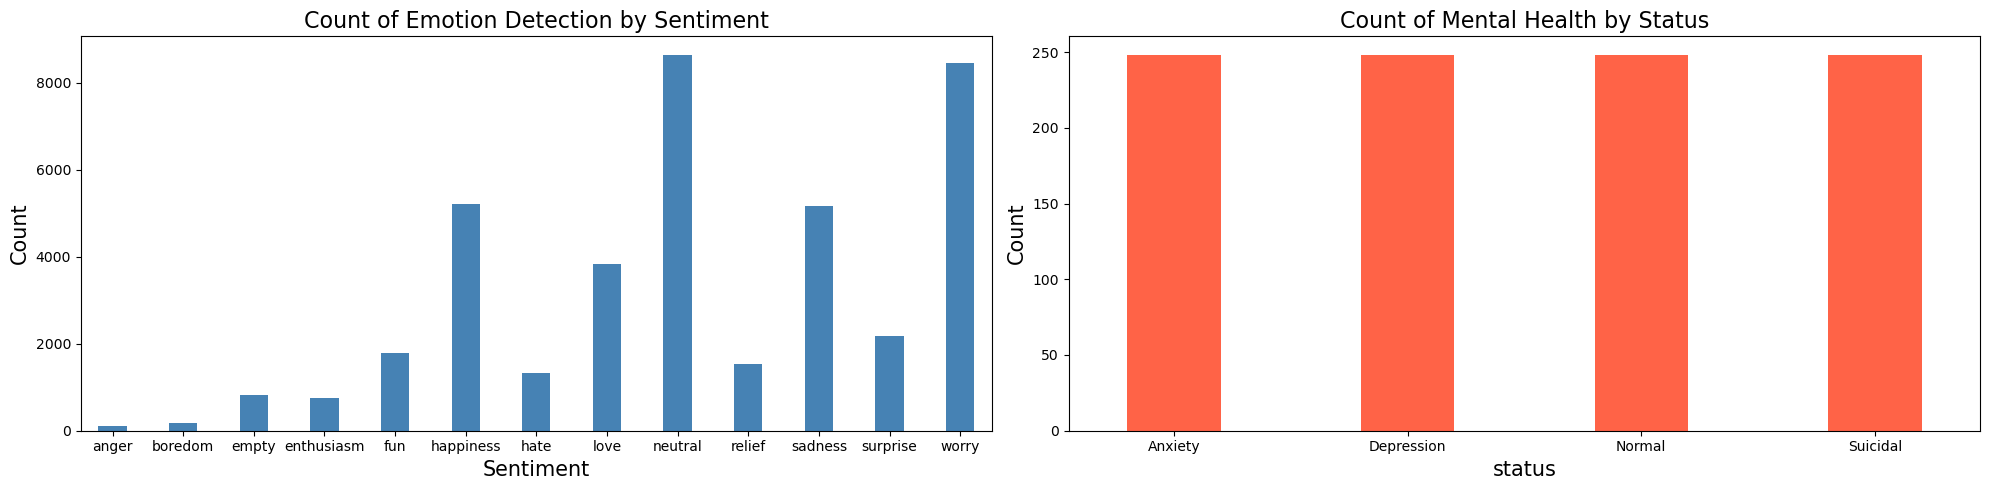

In [13]:
# create a subplot for the count of both datasets
fig, axes = plt.subplots(1, 2, figsize = (20, 5))

# display the count of Emotion Detection by sentiment
emotion_detection_df['sentiment'].value_counts().sort_index().plot(
    kind = 'bar',
    ax = axes[0],
    color = 'steelblue',
    width = 0.4,
    fontsize = 10
)
axes[0].set_title('Count of Emotion Detection by Sentiment', fontsize = 16)
axes[0].set_xlabel('Sentiment', fontsize = 15)
axes[0].set_ylabel('Count', fontsize = 15)
axes[0].tick_params(axis = 'x', labelrotation = 0)

# display the count of Mental Health by status
mental_health_df['status'].value_counts().sort_index().plot(
    kind = 'bar',
    ax = axes[1],
    color = 'tomato',
    width = 0.4,
    fontsize = 10
)
axes[1].set_title('Count of Mental Health by Status', fontsize = 16)
axes[1].set_xlabel('status', fontsize = 15)
axes[1].set_ylabel('Count', fontsize = 15)
axes[1].tick_params(axis = 'x', labelrotation = 0)

plt.tight_layout()
plt.show()

### **1.3 Sentiment Labelling**
Both datasets need 3 class sentiment labels (positive, negative, and neutral) before training:
- Emotion Detection has 13 emotion labels. Apply a simple rule-based mapping (e.g. happiness -> positive, sadness -> negative, surprise -> neutral).
- Mental Health has 4 clinical labels (Anxiety / Depression / Normal / Suicidal), these are not sentiment. Apply VADER (Valence Aware Dictionary and sEntiment Reasoner) to the cleaned text to derive sentiment from the post content.

In [14]:
# VADER (rule-based sentiment scorer)
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon') # VADER's word-score dictionary

# initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/huck/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


#### Run the Sentiment label on both Datasets
Both datasets now carry a 3 class `sentiment` column (positive / negative / neutral).
- **Emotion Detection:** the original 13 emotion labels are mapped to 3 classes (overwriting the old `sentiment` column).
- **Mental Health:** VADER writes to a new `sentiment` column.

In [15]:
# label sentiment for Mental Health dataset
def label_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05: return 'positive'
    elif score <= -0.05: return 'negative'
    else: return 'neutral'

# apply VADER sentiment analysis to the cleaned text and create a new column 'sentiment'
mental_health_df['sentiment'] = mental_health_df['text_clean'].apply(label_sentiment)
print('Columns after VADER labelling:', mental_health_df.columns.tolist())
print()

print("Mental Health Sentiment Distribution (VADER):")
print(mental_health_df['sentiment'].value_counts())

# label sentiment for Emotion Detection dataset
pos_emotions = ['happiness', 'love', 'fun', 'enthusiasm', 'relief']
neg_emotions = ['sadness', 'worry', 'hate', 'anger', 'boredom']
def map_sentiment(label):
    if label in pos_emotions: return 'positive'
    elif label in neg_emotions: return 'negative'
    else: return 'neutral'

emotion_detection_df['sentiment'] = emotion_detection_df['sentiment'].apply(map_sentiment)

print("Emotion Detection Sentiment Distribution:")
print(emotion_detection_df['sentiment'].value_counts())


Columns after VADER labelling: ['text', 'status', 'text_clean', 'sentiment']

Mental Health Sentiment Distribution (VADER):
sentiment
negative    542
positive    405
neutral      45
Name: count, dtype: int64
Emotion Detection Sentiment Distribution:
sentiment
negative    15236
positive    13112
neutral     11652
Name: count, dtype: int64


#### Cross-tab - Clinical Status vs VADER Sentiment
**Analysis Domain Vocabulary Errors:** Compare each clinical condition against VADER's sentiment label.


Clinical status vs VADER sentiment (% per condition):
sentiment   negative  neutral  positive
status                                 
Anxiety         50.8      0.0      49.2
Depression      56.5      2.8      40.7
Normal          42.7     11.3      46.0
Suicidal        68.5      4.0      27.4


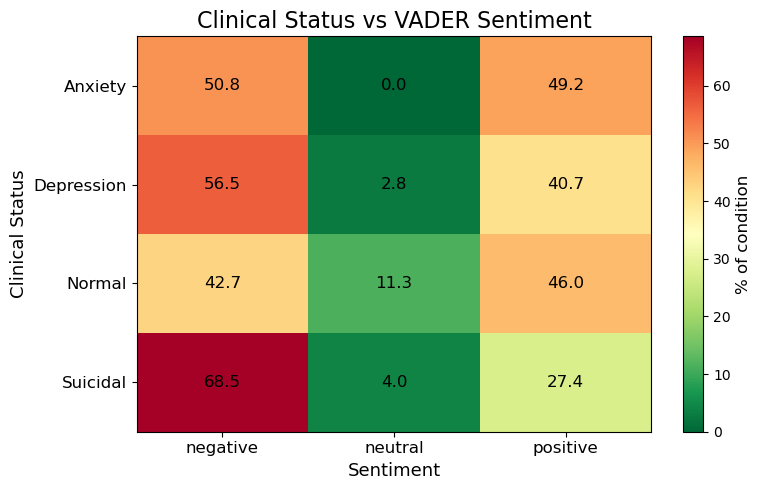

In [16]:
# cross-tab clinical status vs VADER sentiment
crosstab = pd.crosstab(mental_health_df['status'], mental_health_df['sentiment'], normalize = 'index') * 100

# display the cross-tab as a percentage table
print('Clinical status vs VADER sentiment (% per condition):')
print(crosstab.round(1).to_string())

# create a subplot
fig, ax = plt.subplots(figsize = (8, 5))

# display the cross-tab by heatmap
im = ax.imshow(crosstab, cmap = 'RdYlGn_r', aspect = 'auto')

# set tick positions
ax.set_xticks(range(len(crosstab.columns)))
ax.set_yticks(range(len(crosstab.index)))

# set tick labels
ax.set_xticklabels(crosstab.columns, fontsize = 12)
ax.set_yticklabels(crosstab.index, fontsize = 12)

# add values inside cells
for i in range(len(crosstab.index)):
    for j in range(len(crosstab.columns)):
        value = crosstab.iloc[i, j]
        ax.text(j, i, f'{value:.1f}', ha = 'center', va = 'center', fontsize = 12)

ax.set_title('Clinical Status vs VADER Sentiment', fontsize = 16)
ax.set_xlabel('Sentiment', fontsize = 13)
ax.set_ylabel('Clinical Status', fontsize = 13)

# add colorbar
cbar = fig.colorbar(im)
cbar.set_label('% of condition', fontsize = 12)

plt.tight_layout()
plt.savefig('clinical_vs_vader_crosstab.png')
plt.show()

### Train, Validation, and Test Mental Health file
Split the 992 row mental health dataset into:
- **Train set** (713 rows, 72%): used to train Models B, C, D and the baseline ML classifiers
- **Validation set** (80 rows, 8%): used as `eval_dataset` during training (for early stopping)
- **Test set** (199 rows, 20%): held-out evaluation set shared by every model (never seen during training)

The split is stratified by sentiment label so the train/val/test proportions match.

In [17]:
from sklearn.model_selection import train_test_split

# Split Mental Health dataset into 80% train + 20% test (stratified)
train_val_df, test_df = train_test_split(
    mental_health_df[['text_clean', 'sentiment']],
    test_size = 0.20,
    random_state = 42,
    stratify = mental_health_df['sentiment']
)

# carve a proper validation set from the training portion.
train_df, val_df = train_test_split(
    train_val_df,
    test_size = 0.10,
    random_state = 42,
    stratify = train_val_df['sentiment']
)

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")
print(f"\nTrain sentiment distribution:\n{train_df['sentiment'].value_counts()}")
print(f"\nVal sentiment distribution:\n{val_df['sentiment'].value_counts()}")
print(f"\nTest sentiment distribution:\n{test_df['sentiment'].value_counts()}")


Train: 713 rows | Val: 80 rows | Test: 199 rows

Train sentiment distribution:
sentiment
negative    389
positive    291
neutral      33
Name: count, dtype: int64

Val sentiment distribution:
sentiment
negative    44
positive    33
neutral      3
Name: count, dtype: int64

Test sentiment distribution:
sentiment
negative    109
positive     81
neutral       9
Name: count, dtype: int64


#### Split and Save Processed CSVs
Save the cleaned and labelled data so downstream tasks read these CSVs instead of re-running the cleaning pipeline.
- `general_sentiment.csv`: 40,000 cleaned tweets with sentiment
- `mentalhealth_sentiment.csv`: 714 mental health train rows
- `mentalhealth_val.csv`: 79 mental health validation rows
- `mentalhealth_test.csv`: 199 mental health test rows

In [65]:
# Save the processed CSVs so downstream tasks read them directly
base_path = os.getcwd()
emotion_detection_df[['text_clean', 'sentiment']].to_csv(
    os.path.join(base_path, "general_sentiment.csv"), index = False)
train_df.to_csv(os.path.join(base_path, "mentalhealth_sentiment.csv"), index = False)
val_df.to_csv(os.path.join(base_path, "mentalhealth_val.csv"), index = False)
test_df.to_csv(os.path.join(base_path, "mentalhealth_test.csv"), index = False)

print(f"Files saved to: {base_path}")


Files saved to: /Users/huck/Downloads/Swinburne/COS60011 Technology Design Project/group/v2


### **1.4 Perform exploratory data analysis (EDA)**
Visual and quantitative exploration of the two datasets before modelling. Produces five charts and two domain-shift metrics that justify why domain adaptation is needed:
- Chart 1: Sentiment distribution (general vs mental health)
- Chart 2: Text length distribution
- Chart 3: Top 15 words per sentiment per domain
- Chart 4: Vocabulary overlap between the two datasets
- Chart 5: Heat map of clinical status vs VADER sentiment
- Metrics: Vocabulary Overlap (%) and Jensen-Shannon Distance (JSD)

#### Chart 1 & 2: Sentiment Distribution & Text Length Distribution
Two side-by-side plots that compare the source and target datasets:
- Chart 1(left) — grouped bar chart of sentiment counts. Mental health text skews heavily negative after VADER labelling (54%), while tweets are more evenly spread.
- Chart 2(right) — overlapping histograms of word count per post. Tweets are typically under 20 words; mental health posts are 20–100 words. This length gap is one component of the domain shift.

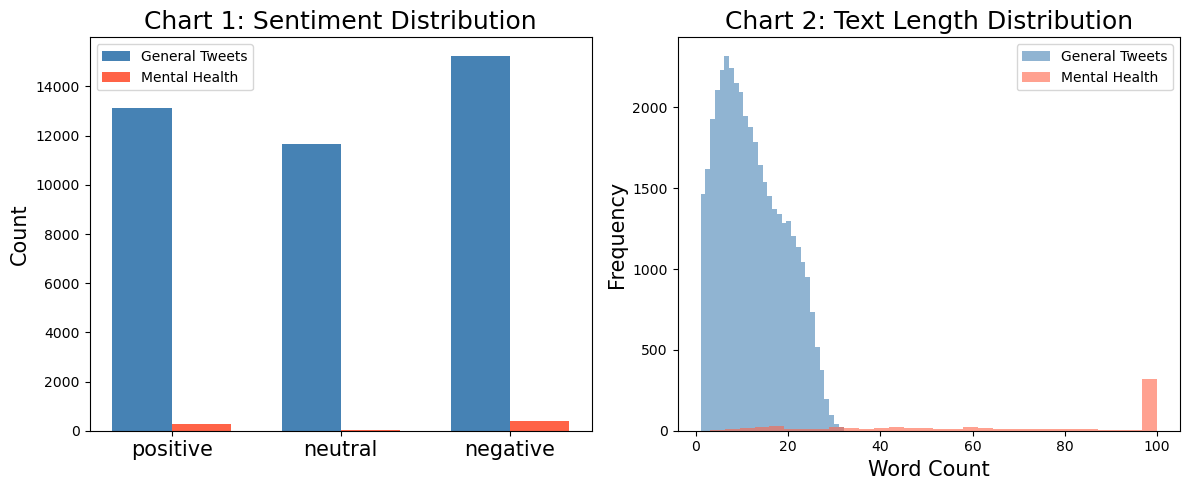

In [66]:
# reload saved CSVs to ensure consistency
general_df = pd.read_csv(os.path.join(base_path, "general_sentiment.csv")) # source domain
train_df = pd.read_csv(os.path.join(base_path, "mentalhealth_sentiment.csv")) # mental health train
test_df = pd.read_csv(os.path.join(base_path, "mentalhealth_test.csv")) # mental health test

# create 1 row, 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sentiment_order = ['positive', 'neutral', 'negative']

# display sentiment distribution by bar chart (Chart 1)
general_counts = general_df['sentiment'].value_counts().reindex(sentiment_order)
train_counts = train_df['sentiment'].value_counts().reindex(sentiment_order)
x = range(len(sentiment_order))
width = 0.35

# blue bars for general sentiment
axes[0].bar([i - width/2 for i in x], general_counts, width, label = 'General Tweets', color = 'steelblue')
# red bars for mental health sentiment
axes[0].bar([i + width/2 for i in x], train_counts, width, label = 'Mental Health', color = 'tomato')
axes[0].set_xticks(list(x)) # set the indices of sentiment categories
axes[0].set_xticklabels(sentiment_order, fontsize = 15)
axes[0].set_title('Chart 1: Sentiment Distribution', fontsize = 18)
axes[0].set_ylabel('Count', fontsize = 15)
axes[0].legend() # distinguish the two datasets

# calc word count for each text in both datasets
general_df['word_count'] = general_df['text_clean'].apply(lambda x: len(str(x).split())) # word count per tweet
train_df['word_count'] = train_df['text_clean'].apply(lambda x: len(str(x).split())) # word count per mental health post

# display text length distribution by histogram (Chart 2)
axes[1].hist(general_df['word_count'].clip(upper = 100), bins = 30, alpha = 0.6, label = 'General Tweets', color = 'steelblue')
axes[1].hist(train_df['word_count'].clip(upper = 100), bins = 30, alpha = 0.6, label = 'Mental Health', color = 'tomato')
axes[1].set_title('Chart 2: Text Length Distribution', fontsize = 18)
axes[1].set_xlabel('Word Count', fontsize = 15)
axes[1].set_ylabel('Frequency', fontsize = 15)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(base_path, "EDA_chart1&2.png"))
plt.show()

#### Chart 3: Top 15 Words per Sentiment per Domain
A 2 × 3 grid (2 datasets × 3 sentiment classes) showing the 15 most frequent non-stopword tokens in each cell.
Reveals the vocabulary signature of each class in each domain.

**Analysis Domain Vocabulary Errors:** visualises which clinical terms appear in mental health but rarely in tweets.

[nltk_data] Downloading package stopwords to /Users/huck/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


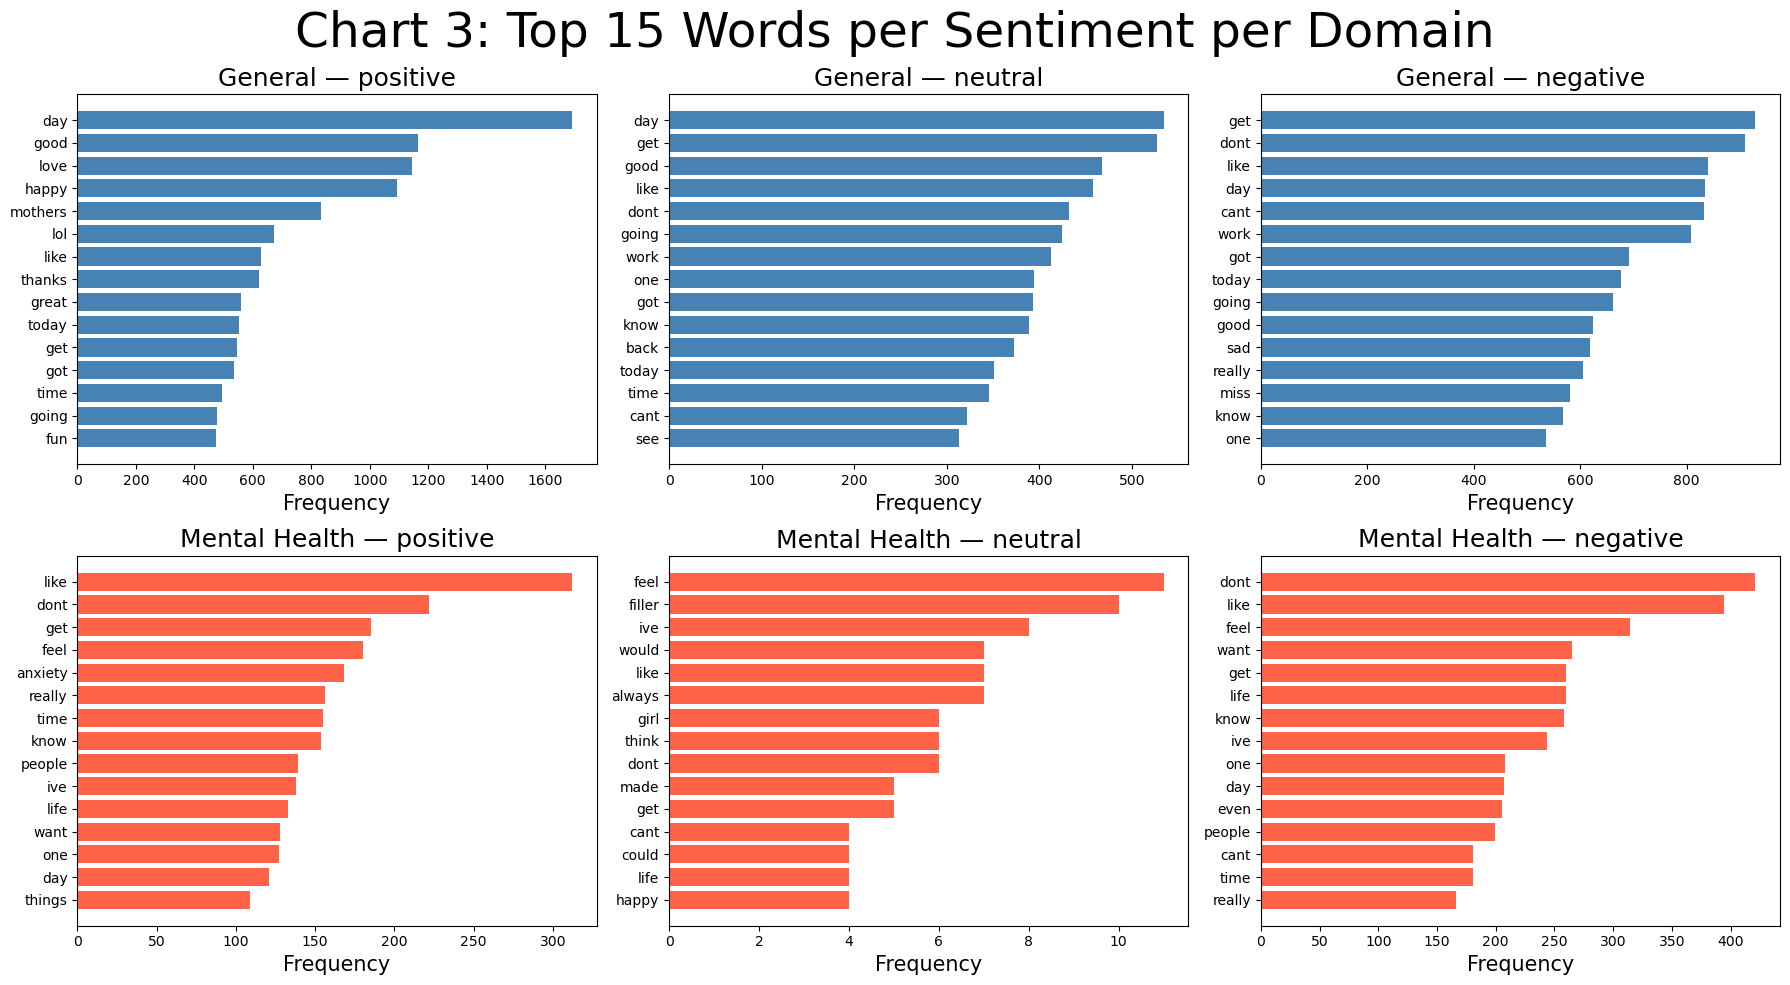

In [67]:
# for counting word frequencies
# Reference: https://www.geeksforgeeks.org/python/counters-in-python-set-1/
from collections import Counter
# remove the common words that do not carry much meaning ("the", "is", etc.)
from nltk.corpus import stopwords
nltk.download('stopwords')

# create a function to get top 15 words for a given sentiment in a dataframe
stop_words = set(stopwords.words('english'))
def top_words(df, sentiment, n = 15):
    texts = df[df['sentiment'] == sentiment]['text_clean'].dropna()
    # tokenization (filter out stop words and very short words, length <= 2)
    words = [w for t in texts for w in tokenize(str(t)) if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n) # return by frequency

# create 2 rows (general vs mental health) x 3 columns (positive, neutral, negative) = 6 subplots
fig, axes = plt.subplots(2, 3, figsize = (18, 10))

# top words per sentiment
for col, sentiment in enumerate(sentiment_order):
    # top words in general dataset (row 0)
    words, counts = zip(*top_words(general_df, sentiment))
    axes[0][col].barh(words[::-1], counts[::-1], color = 'steelblue') # set reverse order
    axes[0][col].set_title(f'General — {sentiment}', fontsize = 18)
    axes[0][col].set_xlabel('Frequency', fontsize = 15)
    # top words in Mental Health dataset (row 1)
    words2, counts2 = zip(*top_words(train_df, sentiment))
    axes[1][col].barh(words2[::-1], counts2[::-1], color = 'tomato') # set reverse order
    axes[1][col].set_title(f'Mental Health — {sentiment}', fontsize = 18)
    axes[1][col].set_xlabel('Frequency', fontsize = 15)

# display top 15 words per sentiment per domain by bar horizontal chart (Chart 3)
plt.suptitle('Chart 3: Top 15 Words per Sentiment per Domain', fontsize = 35)
plt.tight_layout()
# save the figure as EDA_chart3.png
plt.savefig(os.path.join(base_path, "EDA_chart3.png"))
plt.show()

#### Chart 4: Vocabulary Overlap
Bar chart breaking the combined vocabulary into three buckets:
- **Shared:** words appearing in BOTH datasets
- **General Only:** words appearing only in tweets
- **Mental Health Only:** words appearing only in the domain dataset

The chart title shows the overlap percentage. A low overlap (14–15%) is direct quantitative evidence of domain shift: the two datasets largely speak different vocabularies.

**Analysis Domain Vocabulary Errors:** quantifies how much of the vocabulary is domain specific (and therefore unseen by Model A).

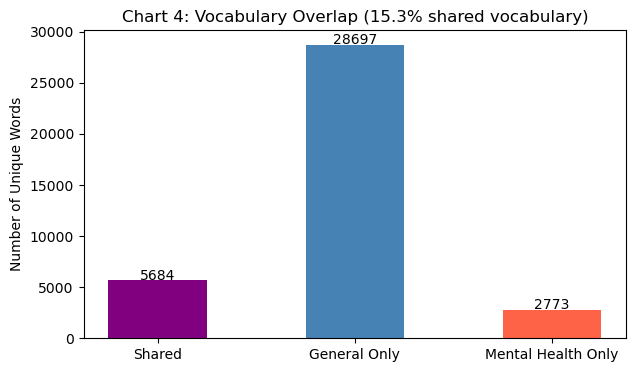

In [68]:
# Vocab overlap is a property of the full dataset, combine train and test to represent the complete mental health dataset
mh_full = pd.concat([train_df, test_df], ignore_index = True) # merge train and test

# tokenization (create a set of unique tokens for each dataset)
general_vocab = set(w for t in general_df['text_clean'].dropna() for w in tokenize(str(t)))
train_vocab = set(w for t in mh_full['text_clean'].dropna() for w in tokenize(str(t)))

# calc the number of shared words, unique words in general, unique words in mental health
shared = len(general_vocab & train_vocab) # shared words
general_only = len(general_vocab - train_vocab) # unique words in general
train_only = len(train_vocab - general_vocab) # unique words in mental health
# calc the percentage of overlap
overlap_pct = shared / len(general_vocab | train_vocab) * 100

# create a subplot for the vocabulary overlap
fig, ax = plt.subplots(figsize = (7, 4))

# display vocabulary overlap by bar chart (Chart 4)
ax.bar(['Shared', 'General Only', 'Mental Health Only'],
       [shared, general_only, train_only],
       color = ['purple', 'steelblue', 'tomato'], width = 0.5)
ax.set_title(f'Chart 4: Vocabulary Overlap ({overlap_pct:.1f}% shared vocabulary)')
ax.set_ylabel('Number of Unique Words')
for i, v in enumerate([shared, general_only, train_only]):
    ax.text(i, v + 50, str(v), ha = 'center')

plt.savefig(os.path.join(base_path, "EDA_chart4.png"))
plt.show()

#### Chart 5: Sentiment % per Mental Health Dataset
Load `mental_heath_unbanlanced.csv`.  
Cross-tab of clinical status (rows) vs VADER-derived sentiment (columns) by heatmap chart, shown as row normalised percentages.

**Analysis Domain Vocabulary Errors:** visualises how each clinical condition (Anxiety/Depression/Normal/Suicidal) distributes across VADER's 3 sentiment classes, revealing where VADER's general domain rules struggle on clinical text.

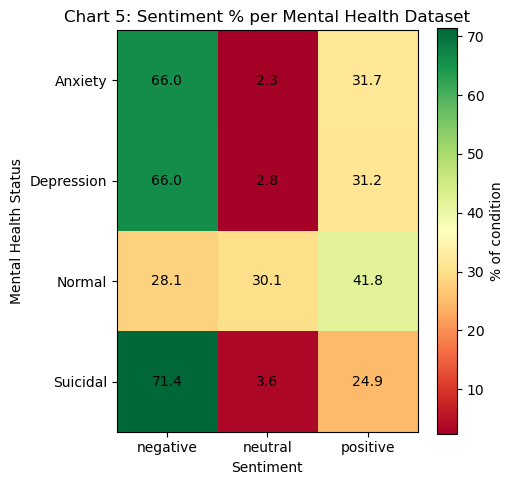

In [69]:
# reload the full unbalanced mental health dataset
mental_health_df_full = pd.read_csv("mental_heath_unbanlanced.csv")
mental_health_df_full['text_clean'] = mental_health_df_full['text'].apply(lambda x: clean_text(str(x)))
mental_health_df_full['sentiment'] = mental_health_df_full['text_clean'].apply(label_sentiment)

# cross-tab (count rows for clinical status and sentiment)
heatmap_data = mental_health_df_full.groupby(['status', 'sentiment']).size().unstack(fill_value = 0)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis = 1),axis = 0) * 100

# create the subplot
fig, ax = plt.subplots(figsize = (5, 5))

# display Mental Health dataset by heatmap (Chart 5)
im = ax.imshow(heatmap_pct, cmap = 'RdYlGn')
ax.set_xticks(range(len(heatmap_pct.columns)))
ax.set_xticklabels(heatmap_pct.columns)
ax.set_yticks(range(len(heatmap_pct.index)))
ax.set_yticklabels(heatmap_pct.index)
for i in range(len(heatmap_pct.index)):
    for j in range(len(heatmap_pct.columns)):
        ax.text(j,i,f"{heatmap_pct.iloc[i, j]:.1f}",ha = 'center',va = 'center')
cbar = fig.colorbar(im)
cbar.set_label('% of condition')
ax.set_title('Chart 5: Sentiment % per Mental Health Dataset')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Mental Health Status')

plt.tight_layout()
plt.savefig(os.path.join(base_path, "EDA_chart5.png"))
plt.show()

### **1.5 Domain Shift Exists in Both Datasets**

Two numbers quantify how different the two datasets are:
- Vocabulary Overlap (%) - percentage of words shared between both datasets (out of all unique words combined). Lower = more linguistic separation.
- Jensen-Shannon Distance (JSD) - how different the word frequency distributions are. Scale 0–1, where 0 = identical and 1 = completely different.

In [70]:
# quantify the domain shift between source (tweets) and target (mental health), using two metrics: vocabulary overlap and Jensen-Shannon distance.
# calculating the Jensen-Shannon Distance between word distributions
# Reference: https://medium.com/@vibhorkashyap/understanding-jensen-shannon-distance-a-friendly-guide-for-data-scientists-4cac664c3381
from scipy.spatial.distance import jensenshannon
# for counting word frequency distributions for both datasets
from collections import Counter

# merge train and test to represent the complete mental health dataset (992 rows)
mh_full = pd.concat([train_df, test_df], ignore_index=True)

# Jensen-Shannon Distance
# tokenization (build word frequency distributions using the full mental health dataset)
tweet_words = [w for t in general_df['text_clean'].dropna().astype(str) for w in tokenize(t)]
mh_words = [w for t in mh_full['text_clean'].dropna().astype(str) for w in tokenize(t)]
# use counter to count the frequency of each word in both datasets
tweet_counter = Counter(tweet_words)
mh_counter = Counter(mh_words)
# use the combined top 10,000 words from both datasets to create frequency distributions
top_vocab = [w for w, _ in (tweet_counter + mh_counter).most_common(10000)]
# convert counts to probability distributions (normalize sum to 1)
tweet_dist = np.array([tweet_counter.get(w, 0) for w in top_vocab], dtype = float)
mh_dist = np.array([mh_counter.get(w, 0) for w in top_vocab], dtype = float)
tweet_dist /= tweet_dist.sum()
mh_dist /= mh_dist.sum()
# returns the Jensen-Shannon Distance
jsd = jensenshannon(tweet_dist, mh_dist)

# Print summary
print(f' Vocabulary overlap: {overlap_pct:.1f}% of combined vocab')
print(f' Jensen-Shannon Dist: {jsd:.4f} (scale 0-1)')

 Vocabulary overlap: 15.3% of combined vocab
 Jensen-Shannon Dist: 0.3040 (scale 0-1)


----------
## **2. Baseline Modeling (Traditional Machine Learning)**
Three classical classifiers (Logistic Regression, Support Vector Machines with a linear kernel, and Naïve Bayes) are trained on TF-IDF features (50,000 features, unigrams and bigrams) under each of the four training conditions (A/B/C/D).  
4 conditions × 3 classifiers = 12 baseline models, all evaluated on the same 199 row Mental Health test set.

In [71]:
# for converting text to numerical features for ML models
from sklearn.feature_extraction.text import TfidfVectorizer
# three classical classifier models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
# evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [72]:
# load domain adaptation data, and rename text_clean column to text
df_tweet = pd.read_csv('general_sentiment.csv').rename(columns = {'text_clean': 'text'})
df_mh_train = pd.read_csv('mentalhealth_sentiment.csv').rename(columns = {'text_clean': 'text'})
df_mh_val = pd.read_csv('mentalhealth_val.csv').rename(columns = {'text_clean': 'text'})
df_mh_test = pd.read_csv('mentalhealth_test.csv').rename(columns = {'text_clean': 'text'})

# drop any rows with missing text or sentiment
df_tweet = df_tweet.dropna(subset = ['text', 'sentiment'])
df_mh_train = df_mh_train.dropna(subset = ['text', 'sentiment'])
df_mh_val = df_mh_val.dropna(subset = ['text', 'sentiment'])
df_mh_test = df_mh_test.dropna(subset = ['text', 'sentiment'])

# prepare test data
X_test = df_mh_test['text'].tolist()
y_test = df_mh_test['sentiment'].tolist()
print(f"tweet: {len(df_tweet)} rows")
print(f"mental health train: {len(df_mh_train)} rows")
print(f"mental health val: {len(df_mh_val)} rows")
print(f"mental health test:  {len(df_mh_test)} rows")


tweet: 39902 rows
mental health train: 713 rows
mental health val: 80 rows
mental health test:  199 rows


### **TF-IDF**
TF-IDF (Term Frequency and Inverse Document Frequency) converts text into a numerical vector where each dimension represents a word, weighted by:
- TF: how often the word appears in the dataset
- IDF: how rare the word is across all datasets (rare words get higher weight)

In [73]:
# combine all texts for TF-IDF vectorizer fitting
all_texts = df_tweet['text'].tolist() + df_mh_train['text'].tolist() + X_test

vectorizer = TfidfVectorizer(
    max_features = 50000, # limit to top 50000 features
    ngram_range = (1, 2), # include unigrams and bigrams
    min_df = 2 # ignore words that appear in less than 2 data points
)

# fit the vectorizer on all texts to build the vocabulary and print the number of features
vectorizer.fit(all_texts)
print(f"TF-IDF vectorizer: {len(vectorizer.vocabulary_):,} features")

TF-IDF vectorizer: 50,000 features


### **Four Training Conditions (A / B / C / D)**
- A (General only): use the general sentiment dataset (40,000 tweets) to train a model and test it on the mental health test set, to measures how well general knowledge transfers with no adaptation.
- B (Domain only): use the mental health train set (793 rows) to train a model and test it on the mental health test set, to measures performance when only the small domain set is available.
- C (Sequential): first train on the general sentiment dataset (stage 1), then fine-tune on the mental health train set (stage 2), and test on the mental health test set.
- D (Mixed): combine the general sentiment and mental health train datasets to train a model, and test on the mental health test (identical to C in baseline ML).

In [74]:
# transform each training condition into TF-IDF feature vectors

# A: train on general sentiment (tweet) dataset only
X_A = vectorizer.transform(df_tweet['text'].tolist())
y_A = df_tweet['sentiment'].tolist()

# B: train on mental health (domain) dataset only
X_B = vectorizer.transform(df_mh_train['text'].tolist())
y_B = df_mh_train['sentiment'].tolist()

# C & D: combine both datasets
combined_texts = df_tweet['text'].tolist() + df_mh_train['text'].tolist() # train on the general sentiment dataset (stage 1)
combined_labels = df_tweet['sentiment'].tolist() + df_mh_train['sentiment'].tolist() # train on the mental health domain dataset (stage 2)
X_CD = vectorizer.transform(combined_texts)
y_CD = combined_labels

# transform the mental health test set
X_test_vec = vectorizer.transform(X_test)

# print the shapes of 4 training conditions and the test set for verification
print(f'A: {X_A.shape}')
print(f'B: {X_B.shape}')
print(f'C/D: {X_CD.shape}')
print(f'Test: {X_test_vec.shape}')

A: (39902, 50000)
B: (713, 50000)
C/D: (40615, 50000)
Test: (199, 50000)


### **Machine Learning Models:** 
- **Logistic Regression**  
Imagine drawing a line on a graph to separate "positive" and "negative" points, then extending that idea to handle three classes.  

- **Support Vector Machines (SVM)**  
Also draws a separating line, but specifically to place that line as far as possible from the nearest points on both sides, which is called maximising the margin.  

- **Naïve Bayes**  
Uses probability to classify text, if the word "happy" appears, how likely is this post to be positive? Assumes every word is independent of every other word.  

In [75]:
# Store the results for each model
results = []

# Define the conditions for each model
conditions = {
    'A (General Only)': (X_A, y_A), # tweets only
    'B (Domain Only)': (X_B, y_B), # mental health only
    'C (Sequential)': (X_CD, y_CD), # combined
    'D (Mixed)': (X_CD, y_CD), # combined
}
# Define the three classifiers
classifiers = {
    # Logistic Regression
    'Logistic Regression': LogisticRegression(
        max_iter = 1000, # maximum 1000 iterations to converge
        class_weight = 'balanced', # handle class imbalance by adjusting weights inversely proportional to class frequencies
        random_state = 42
    ),
    # Support Vector Machines (SVM)
    'SVM (linear)': LinearSVC(
        max_iter = 2000,
        class_weight = 'balanced',
        random_state = 42
    ),
    # Naïve Bayes
    'Naïve Bayes': MultinomialNB(
        alpha = 1.0 # smoothing parameter to handle zero probabilities
    ),
}

### **Macro F1 Score**  
A classification metric that calculates the unweighted mean of the F1 scores across all classes in a multi-class or multi-label model, every class contributes equally, regardless of how many samples it has. Use it as primary metric because the mental health data is class-imbalanced.  
  
Run the train and evaluate loop, and record Accuracy and Macro F1 for all models, and store their predictions.

In [76]:
# store all predictions for each model
all_predictions = {}

# loop through each condition and classifier, train the model, make predictions, and calculate metrics
for condition_name, (X_train, y_train) in conditions.items(): # training condition
    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train) # train the classifier
        y_pred = clf.predict(X_test_vec) # predict on the test set

        # calc metrics
        acc = accuracy_score(y_test, y_pred) # overall accuracy
        f1 = f1_score(y_test, y_pred, average = 'macro', zero_division = 0) # Macro average F1 score across all classes, set zero_division=0 to avoid errors if a class is not predicted
        
        # store predictions
        key = f'{condition_name} | {clf_name}'
        all_predictions[key] = y_pred
        results.append({
            'Condition': condition_name,
            'Classifier': clf_name,
            'Accuracy': round(acc * 100, 2),
            'Macro F1': round(f1 * 100, 2),
        })
        # print the results for the model
        print(f'{condition_name} | {clf_name}')
        print(f'Accuracy: {acc:.4f}  |  Macro F1: {f1:.4f}')

A (General Only) | Logistic Regression
Accuracy: 0.5980  |  Macro F1: 0.3810
A (General Only) | SVM (linear)
Accuracy: 0.6131  |  Macro F1: 0.4385
A (General Only) | Naïve Bayes
Accuracy: 0.5879  |  Macro F1: 0.3256
B (Domain Only) | Logistic Regression
Accuracy: 0.6281  |  Macro F1: 0.4341
B (Domain Only) | SVM (linear)
Accuracy: 0.7035  |  Macro F1: 0.4782
B (Domain Only) | Naïve Bayes
Accuracy: 0.5477  |  Macro F1: 0.2359
C (Sequential) | Logistic Regression
Accuracy: 0.7035  |  Macro F1: 0.5294
C (Sequential) | SVM (linear)
Accuracy: 0.6482  |  Macro F1: 0.4750
C (Sequential) | Naïve Bayes
Accuracy: 0.5930  |  Macro F1: 0.3271
D (Mixed) | Logistic Regression
Accuracy: 0.7035  |  Macro F1: 0.5294
D (Mixed) | SVM (linear)
Accuracy: 0.6482  |  Macro F1: 0.4750
D (Mixed) | Naïve Bayes
Accuracy: 0.5930  |  Macro F1: 0.3271


### **The DataFrame for Baseline ML result**
Collect the 12 baseline results into a single DataFrame, sort by Macro F1 descending, and print so the strongest models appear at the top.

In [77]:
# convert the list of dicts into a DataFrame for better display
df_results = pd.DataFrame(results)

# sort the results by Macro F1 score in descending order
df_results_sorted = df_results.sort_values('Macro F1', ascending = False)
print(df_results_sorted.to_string(index = False))

       Condition          Classifier  Accuracy  Macro F1
  C (Sequential) Logistic Regression     70.35     52.94
       D (Mixed) Logistic Regression     70.35     52.94
 B (Domain Only)        SVM (linear)     70.35     47.82
  C (Sequential)        SVM (linear)     64.82     47.50
       D (Mixed)        SVM (linear)     64.82     47.50
A (General Only)        SVM (linear)     61.31     43.85
 B (Domain Only) Logistic Regression     62.81     43.41
A (General Only) Logistic Regression     59.80     38.10
  C (Sequential)         Naïve Bayes     59.30     32.71
       D (Mixed)         Naïve Bayes     59.30     32.71
A (General Only)         Naïve Bayes     58.79     32.56
 B (Domain Only)         Naïve Bayes     54.77     23.59


### **Display Baseline ML result by bar chart**
Create a bar chart with Condition on x-axis, Macro F1 on y-axis, and different colors for each Classifier.

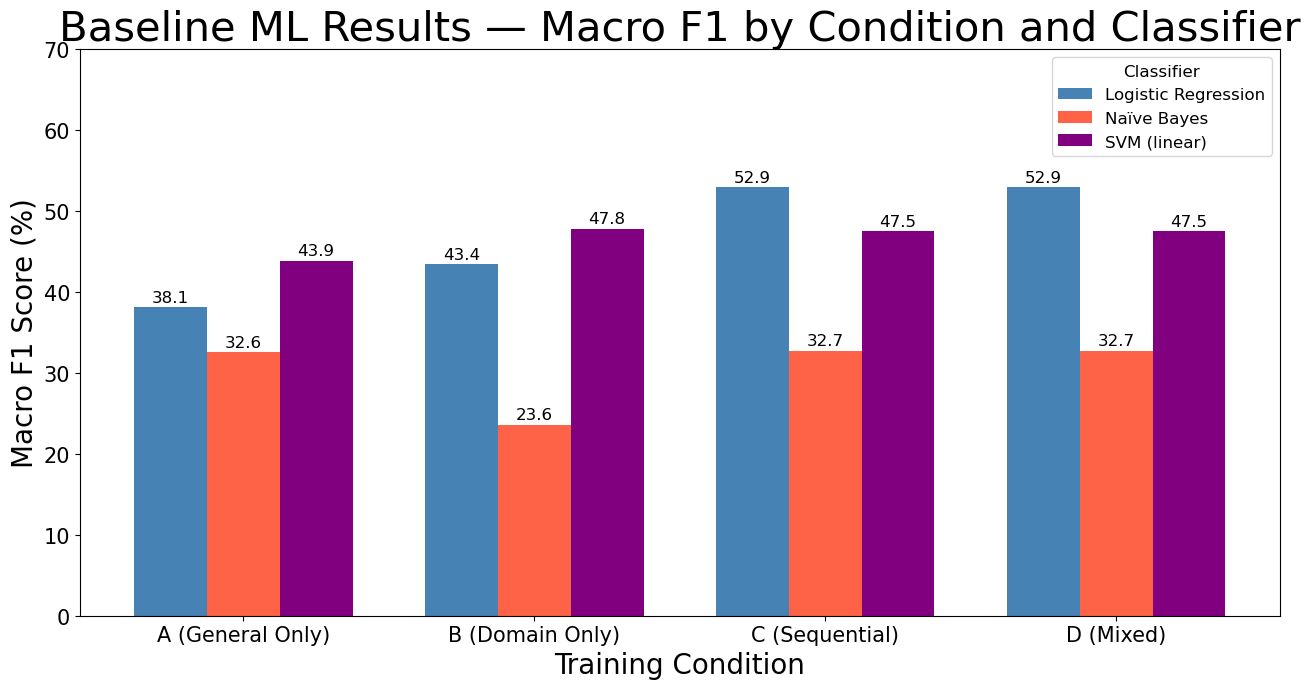

In [78]:
# create the subplot
fig, ax = plt.subplots(figsize = (13, 7))

pivot = df_results.pivot(index = 'Condition', columns = 'Classifier', values = 'Macro F1')

x = np.arange(len(pivot.index)) # number of conditions for label locations
colors = ['steelblue', 'tomato', 'purple']
width = 0.25

for i, (clf_name, color) in enumerate(zip(pivot.columns, colors)):
    bars = ax.bar(x + i * width, pivot[clf_name], width, label = clf_name, color = color)
    # add value labels on top of each bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}', ha = 'center', va = 'bottom', fontsize = 12)

ax.set_xlabel('Training Condition', fontsize = 20)
ax.set_ylabel('Macro F1 Score (%)', fontsize = 20)
ax.set_title('Baseline ML Results — Macro F1 by Condition and Classifier', fontsize = 30)
ax.set_xticks(x + width)
ax.set_xticklabels(pivot.index, fontsize = 15)
ax.tick_params(axis='y', labelsize = 15)
ax.legend(title = 'Classifier', loc = 'upper right', fontsize = 12, title_fontsize = 12)
ax.set_ylim(0, 70)

plt.tight_layout()
plt.savefig('baseline_ml_results.png')

### **The best Baseline ML model based on Macro F1 score**
Identify the single best baseline (highest Macro F1 across the 12 trained models) and print its classification report. 

In [79]:
# identify the best Baseline ML model based on Macro F1 score
best = df_results_sorted.iloc[0]
best_key = f"{best['Condition']} | {best['Classifier']}"
best_pred = all_predictions[best_key]

# print the classification report
print(classification_report(y_test, best_pred))

# print the best model and its mertics
print(f'The best performing model: {best_key}')
# print the classification report for the best model
print(f'Macro F1: {best["Macro F1"]}% | Accuracy: {best["Accuracy"]}%')

              precision    recall  f1-score   support

    negative       0.68      0.94      0.79       109
     neutral       0.17      0.22      0.19         9
    positive       0.97      0.44      0.61        81

    accuracy                           0.70       199
   macro avg       0.61      0.53      0.53       199
weighted avg       0.78      0.70      0.69       199

The best performing model: C (Sequential) | Logistic Regression
Macro F1: 52.94% | Accuracy: 70.35%


### **Display the Confusion Matrix for the best model by Heatmap**
A 2 × 2 grid of confusion matrix heatmaps (one per condition, each showing the best classifier for that condition).  
Each cell in the matrix represents how many times the actual label was X but the model predicted Y.
The larger the numbers along the diagonal, which means those are the correct predictions.

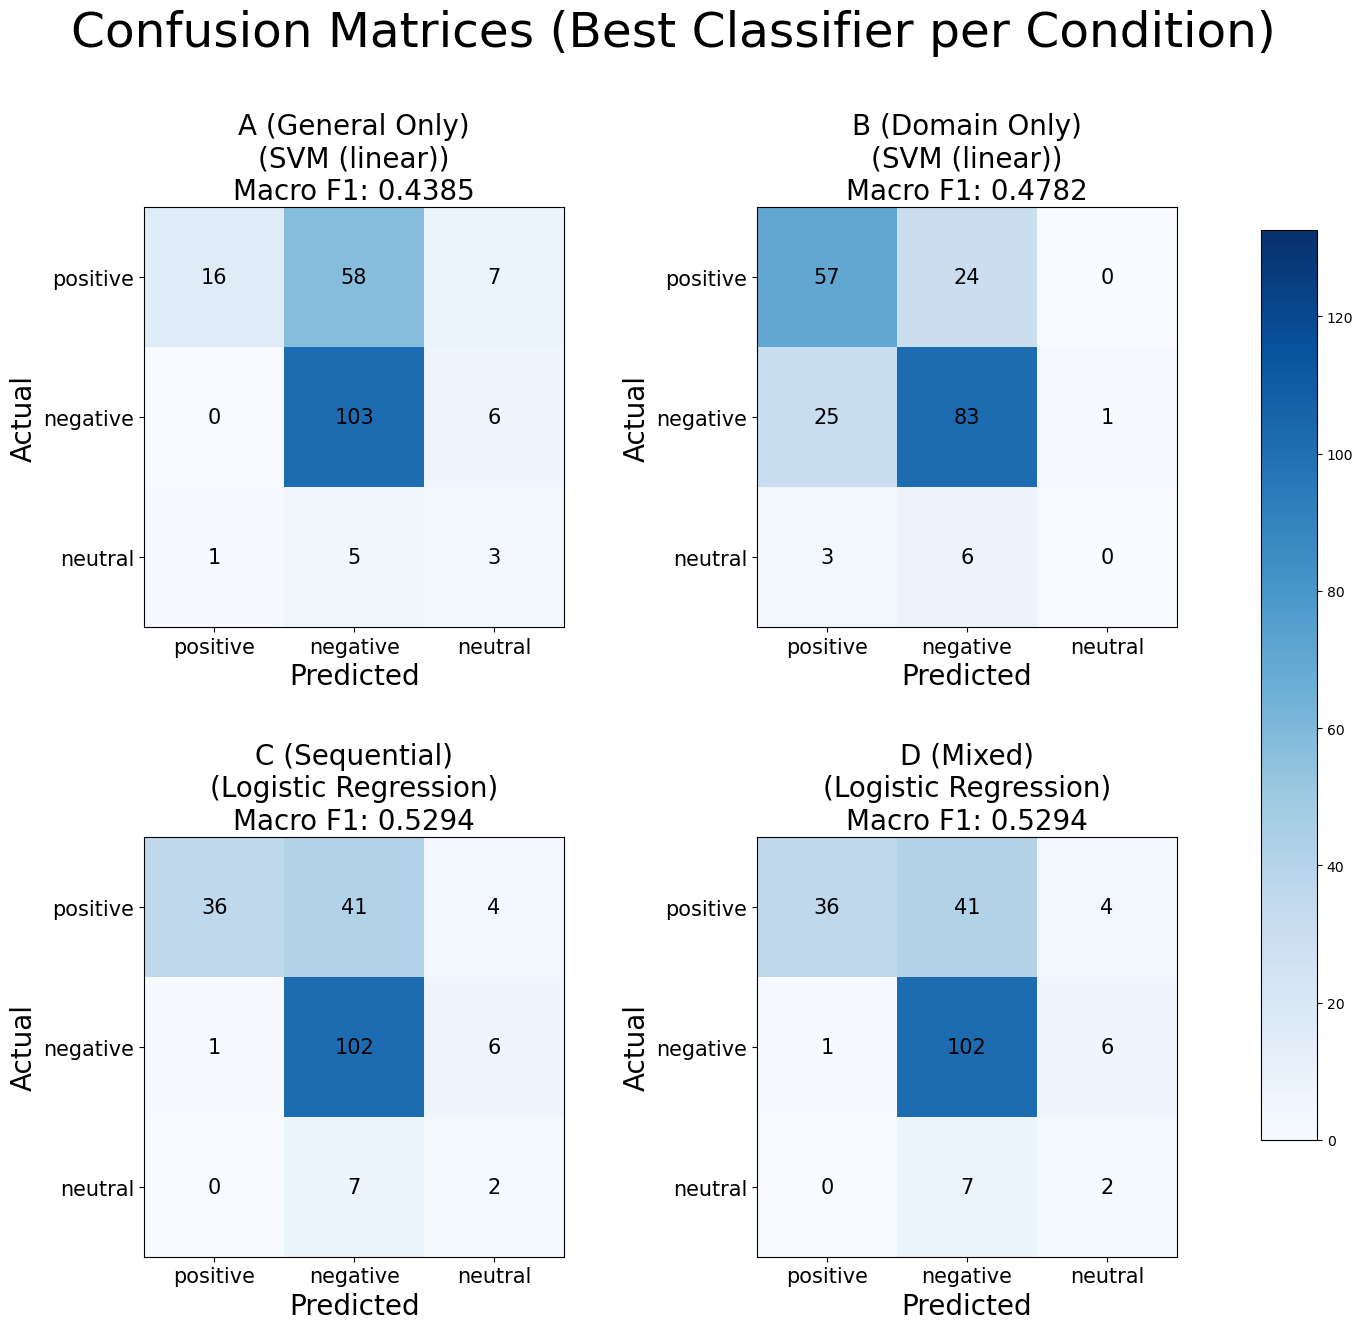

In [80]:
# 2 rows, 2 columns subplots for the 4 conditions (A, B, C, D)
fig, axes = plt.subplots(2, 2, figsize = (14, 13))

axes = axes.flatten() # flatten to 1D for easy iteration
label_order = ['positive', 'negative', 'neutral']

for ax, condition_name in zip(axes,['A (General Only)', 'B (Domain Only)', 'C (Sequential)', 'D (Mixed)']):
    # find the best classifier for this condition based on Macro F1
    cond_results = df_results[df_results['Condition'] == condition_name]
    best_clf = cond_results.loc[cond_results['Macro F1'].idxmax(),'Classifier']
    key = f'{condition_name} | {best_clf}'
    pred = all_predictions[key]

    # confusion matrix
    cm = confusion_matrix(y_test, pred, labels = label_order)

    # display confusion matrix by heatmap
    im = ax.imshow(cm, cmap = 'Blues', vmax=cm.max() * 1.3) # reversed color scheme for better visibility of lower values
    ax.set_xticks(range(len(label_order)))
    ax.set_yticks(range(len(label_order)))
    ax.set_xticklabels(label_order, fontsize = 15)
    ax.set_yticklabels(label_order, fontsize = 15)

    # add value labels in each heatmap cell
    for i in range(len(label_order)):
        for j in range(len(label_order)):
            ax.text(j, i, str(cm[i, j]), ha = 'center', va = 'center', fontsize = 15)
    f1 = f1_score(y_test, pred, average = 'macro', zero_division = 0) # Macro F1 score
    ax.set_title(f'{condition_name}\n({best_clf})\nMacro F1: {f1:.4f}', fontsize = 20)
    ax.set_xlabel('Predicted', fontsize = 20)
    ax.set_ylabel('Actual', fontsize = 20)

plt.suptitle('Confusion Matrices (Best Classifier per Condition)', fontsize = 35, y = 1.02)

# add color bar to the right of the subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.04, 0.7]) # [left, bottom, width, height]
fig.colorbar(im, cax = cbar_ax)

plt.tight_layout(rect = [0, 0, 0.9, 1]) # adjust layout to make room for the color bar
plt.subplots_adjust(hspace = 0.5) # add more space between rows for better readability
plt.savefig('confusion_matrices.png')
plt.show()

### **Save the predictions and true labels**
Persist the baseline ML results (Accuracy + Macro F1 for each model):  
- `results_baseline_ml.csv`: summary table with Accuracy and Macro F1 for the 12 models.
- `predictions_baseline_ml.csv`: long format table with one row per (model, test sample).

In [81]:
# save the results DataFrame to a CSV file
df_results.to_csv('results_baseline_ml.csv', index = False)

# save per row predictions in long format
records = []
for model_name, preds in all_predictions.items():
    for i, pred in enumerate(preds):
        records.append({
            'model': model_name,
            'row_index': i,
            'predicted': pred,
            'actual': y_test[i],
        })
pd.DataFrame(records).to_csv('predictions_baseline_ml.csv', index = False)

----------
## **3. Transformer-Based Modeling (DistilBERT)**
DistilBERT is a distilled (smaller, faster, lighter) version of BERT developed by Hugging Face. It captures both semantic and syntactic context.  
  
This section trains four DistilBERT models (A, B, C, D), each under a different training-data condition (same architecture, same hyperparameters, only the data changes):  
- Model A: General Only (train only on general dataset)
- Model B: Domain Only Fine-Tuning (train only on domain dataset)
- Model C: Sequential Transfer Learning (train on general dataset, then fine-tune on domain dataset) -> **Transfer Learning Technique (Sequential fine-tuning (general -> domain))**
- Model D: Mixed Training (train on combined dataset and oversample 5 times) -> **Transfer Learning Technique (Dataset weighting strategies)**

In [82]:
from transformers import (
    DistilBertTokenizer, # tokenises raw text into DistilBERT subword tokens
    DistilBertForSequenceClassification, # for fine-tuning DistilBERT on sentiment classification
    TrainingArguments, # for configuring the objectives and hyperparameters of the training process
    Trainer # for handling the training loop
)

# create a HuggingFace dataset from pandas DataFrame
from datasets import Dataset

# for evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


### **Hyperparameters**
Define the training settings shared by all four DistilBERT models.

In [83]:
# define hyperparameters
MODEL_NAME = 'distilbert-base-uncased' # pretrained checkpoint from HuggingFace Hub
TWEET_MAX_LEN = 64 # general tweets dataset max length
MH_MAX_LEN = 256 # mental health dataset max length
BATCH_SIZE = 16 # samples per gradient step
MAX_EPOCHS = 5 # maximum number of training epochs
WARMUP_RATIO  = 0.1 # warmup steps as a ratio of total training steps
WEIGHT_DECAY  = 0.01 # L2 regularization to prevent overfitting
LR_STAGE1 = 2e-5 # standard learning rate for Models A, B, D and Model C's general sentiment fine-tuning
LR_STAGE2 = 1e-5 # half-strength rate for Model C's mental health fine-tuning to prevent catastrophic forgetting

# label mapping for the three sentiment classes
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2} # text to integer mapping
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'} # integer to text mapping
NUM_LABELS = 3 # number of sentiment classes
CLASS_NAMES = ['negative', 'neutral', 'positive']


### **Tokenizer**
Break each sentence into subword tokens and convert to integer IDs.

In [84]:
# load the pretrained tokenizer that matches DistilBERT-base-uncased
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# test the tokenizer on a sample text to see how it converts text to token IDs
sample = "I\'m feeling anxious and hopeless today"
enc = tokenizer(sample, max_length = MH_MAX_LEN, padding = 'max_length', truncation = True, return_tensors = 'pt')
print(sample)
print(f'Top 10 tokens: {enc["input_ids"][0][:10].tolist()}')

# tokenization function to convert raw text and labels into the format required by the HuggingFace Trainer
def tokenize_data(texts, labels, max_length = MH_MAX_LEN):
    encodings = tokenizer(list(texts), truncation = True, padding = 'max_length', max_length = max_length)
    encodings['labels'] = [LABEL2ID[l] for l in labels]
    return Dataset.from_dict(encodings)

# helper called by Trainer after each evaluation epoch
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = -1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average = 'macro', zero_division = 0)
    return {'accuracy': acc, 'macro_f1': f1}

# tokenize the new validation set (used as eval_dataset during training)
X_val = df_mh_val['text'].tolist()
y_val = df_mh_val['sentiment'].tolist()
val_ds = tokenize_data(X_val, y_val, max_length = MH_MAX_LEN)

# tokenize the test set (used only for final evaluation, never during training)
X_test = df_mh_test['text'].tolist()
y_test = df_mh_test['sentiment'].tolist()
test_ds = tokenize_data(X_test, y_test, max_length = MH_MAX_LEN)


I'm feeling anxious and hopeless today
Top 10 tokens: [101, 1045, 1005, 1049, 3110, 11480, 1998, 20625, 2651, 102]


### **Trainer**
Set up the HuggingFace Trainer, which wraps the entire training loop (batching, gradient steps, optimiser, scheduler, evaluation, logging).
  
**AdamW (Adam with Weight Decay):**
A smarter version of Adam that decouples weight decay from the gradient update step. Instead of adding weight decay to the loss function, it applies weight decay directly during the parameter update, leading to more consistent regularization and better generalisation. Selected via `optim='adamw_torch'` in `TrainingArguments`.

In [85]:
from transformers import EarlyStoppingCallback

# build a Trainer
def make_trainer(model, train_ds, eval_ds, learning_rate, output_dir):
    # the settings for all models (except learning_rate and output_dir which are passed as arguments)
    args = TrainingArguments(
        output_dir = output_dir,
        num_train_epochs = MAX_EPOCHS, 
        per_device_train_batch_size = BATCH_SIZE, # train batch size
        per_device_eval_batch_size = BATCH_SIZE, # evaluation batch size
        learning_rate = learning_rate,
        weight_decay = WEIGHT_DECAY, # L2 regularisation to prevent overfitting
        warmup_ratio = WARMUP_RATIO, # warmup steps as a ratio of total training steps
        lr_scheduler_type = 'linear', # linear learning rate decay after warmup
        optim = 'adamw_torch', # AdamW optimiser for better convergence with transformers
        eval_strategy = 'epoch', # evaluate after each epoch
        save_strategy = 'epoch', # save checkpoint after each epoch
        save_total_limit = 2, # limit the total number of saved checkpoints to 2 (best + last)
        load_best_model_at_end = True, # load the best model at the end of training
        metric_for_best_model = 'macro_f1', # use Macro F1 score to evaluate the best model
        greater_is_better = True,
        logging_steps = 100,
        seed = 42,
        report_to = 'none',
        label_names = ['labels'],
        fp16 = torch.cuda.is_available(), # use mixed precision if GPU is available for faster training and lower memory usage
    )

    trainer = Trainer(
        model = model,
        args = args,
        train_dataset = train_ds,
        eval_dataset = eval_ds,
        compute_metrics = compute_metrics,
        callbacks = [EarlyStoppingCallback(early_stopping_patience = 2)], # stop training if eval metric does not improve for 2 consecutive evaluation steps (epochs)
    )
    return trainer

# run inference on the test set and convert integer predictions back to strings
def get_predictions(trainer):
    output = trainer.predict(test_ds)
    y_pred_ids = np.argmax(output.predictions, axis = -1)
    y_pred_str = [ID2LABEL[p] for p in y_pred_ids]
    return y_pred_str

# store the results and predictions for each model
distilbert_results = {} # to store accuracy and Macro F1 scores
distilbert_predictions = {} # to store the predicted labels for each model


### **Model A - General Only (No Domain Adaptation)**
Training data: 40,000 tweets (split 90% train / 10% val for early stopping).  
Test data: mental health test set.  
Purpose: measure how well general domain knowledge transfers to the mental health domain without adaptation.

In [86]:
# Model A: train on general sentiment (tweet) dataset only
model_A = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_LABELS,
    id2label = ID2LABEL,
    label2id = LABEL2ID,
)

# split tweet dataset into 90% train / 10% val for early stopping
from sklearn.model_selection import train_test_split as _tts
df_tweet_train, df_tweet_val = _tts(df_tweet, test_size = 0.10, random_state = 42, stratify = df_tweet['sentiment'])

# tokenize the training data (TWEET_MAX_LEN = 64)
train_ds_A = tokenize_data(df_tweet_train['text'].tolist(), df_tweet_train['sentiment'].tolist(), max_length = TWEET_MAX_LEN)
val_ds_A = tokenize_data(df_tweet_val['text'].tolist(), df_tweet_val['sentiment'].tolist(), max_length = TWEET_MAX_LEN)
print(f'Model A (General Only) — Train: {len(train_ds_A)} | Val: {len(val_ds_A)}')

# create a Trainer for Model A and train the model
trainer_A = make_trainer(model_A, train_ds_A, val_ds_A, LR_STAGE1, 'checkpoints/model_A')
trainer_A.train()

# save the trained model and tokenizer to the checkpoints directory
trainer_A.save_model('checkpoints/model_A')
tokenizer.save_pretrained('checkpoints/model_A')

# get predictions, calc metrics, calc F1, and print the results for Model A
y_pred_A = get_predictions(trainer_A)
acc_A = accuracy_score(y_test, y_pred_A)
f1_A = f1_score(y_test, y_pred_A, average = 'macro', zero_division = 0)
print(f'Model A: Accuracy = {acc_A * 100:.2f}% | Macro F1 = {f1_A * 100:.2f}%')

# store the results and predictions for Model A
distilbert_results['A (General Only)'] = {'Accuracy': round(acc_A * 100, 2), 'Macro F1': round(f1_A * 100, 2)}
distilbert_predictions['A (General Only)'] = y_pred_A


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Model A (General Only) — Train: 35911 | Val: 3991


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.850832,0.864943,0.614132,0.588739


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

### **Model B - Domain Only (No Transfer Learning)**
Training data: 714 mental health train rows only.  
Test data: mental health test set.  
Purpose: measure performance when the model only ever sees the limited domain dataset.

In [ ]:
# Model B: train on mental health (domain) dataset only
model_B = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels = NUM_LABELS, id2label = ID2LABEL, label2id = LABEL2ID
)

# tokenize the training data for Model B (mental health domain)
train_ds_B = tokenize_data(df_mh_train['text'].tolist(), df_mh_train['sentiment'].tolist(), max_length = MH_MAX_LEN)
print(f'Model B (Domain Only) — Train: {len(train_ds_B)} | Val: {len(val_ds)}')

# create a Trainer for Model B and train the model
trainer_B = make_trainer(model_B, train_ds_B, val_ds, LR_STAGE1, 'checkpoints/model_B')
trainer_B.train()

# save the trained model to the checkpoints directory
trainer_B.save_model('checkpoints/model_B')

# get predictions, calc metrics, calc F1, and print the results for Model B
y_pred_B = get_predictions(trainer_B)
acc_B = accuracy_score(y_test, y_pred_B)
f1_B = f1_score(y_test, y_pred_B, average = 'macro', zero_division = 0)
print(f'Model B: Accuracy = {acc_B * 100:.2f}% | Macro F1 = {f1_B * 100:.2f}%')

# store the results and predictions for Model B
distilbert_results['B (Domain Only)'] = {'Accuracy': round(acc_B * 100, 2), 'Macro F1': round(f1_B * 100, 2)}
distilbert_predictions['B (Domain Only)'] = y_pred_B


### **Model C - Sequential Transfer Learning**
Two stage fine-tuning that transfers general language knowledge into the mental health domain.

Training data:
- **Stage 1:** starts from the Model A checkpoint (general sentiment).
- **Stage 2:** fine-tunes on the mental health training set with a reduced learning rate (1e-5 vs 2e-5).  
Test data: mental health test set.  
Purpose: the reduced stage 2 learning rate lets the model gently adapt to the new domain without overwriting the general language patterns stage 1 learnt, which called preventing catastrophic forgetting. **Transfer Learning Technique (Sequential fine-tuning (general -> domain))**

In [ ]:
# Model C: sequential fine-tuning
model_C = DistilBertForSequenceClassification.from_pretrained(
    'checkpoints/model_A', # load the checkpoint from Model A (general sentiment Stage 1)
    num_labels = NUM_LABELS,
    id2label = ID2LABEL,
    label2id = LABEL2ID,
)

# tokenize the mental health training split (same as Model B)
train_ds_C = tokenize_data(df_mh_train['text'].tolist(), df_mh_train['sentiment'].tolist(), max_length = MH_MAX_LEN)
print(f'Model C (Sequential) — Train: {len(train_ds_C)} | Val: {len(val_ds)}')

# create a Trainer for Model C and train the model
trainer_C = make_trainer(model_C, train_ds_C, val_ds, LR_STAGE2, 'checkpoints/model_C')
trainer_C.train()

# save the trained model to the checkpoints directory
trainer_C.save_model('checkpoints/model_C')

# get predictions, calc metrics, calc F1, and print the results for Model C
y_pred_C = get_predictions(trainer_C)
acc_C = accuracy_score(y_test, y_pred_C)
f1_C = f1_score(y_test, y_pred_C, average = 'macro', zero_division = 0)
print(f'Model C: Accuracy = {acc_C * 100:.2f}% | Macro F1={f1_C * 100:.2f}%')

# store the results and predictions for Model C
distilbert_results['C (Sequential)'] = {'Accuracy': round(acc_C * 100, 2), 'Macro F1': round(f1_C * 100, 2)}
distilbert_predictions['C (Sequential)'] = y_pred_C


### **Model D - Mixed Training and Dataset Weighting**
A single training run on the combined general and domain corpus, with dataset weighting applied to the under-represented mental health rows.

Training data: general dataset and mental health domain dataset combined, with the mental health rows oversampled 5 times to compensate for the 50:1 corpus imbalance.  
Test data: mental health test set.  
Purpose: implement a **Transfer Learning Technique (dataset weighting strategies)**.

In [ ]:
# oversample 5 times to give more weight to the mental health domain data
df_mh_oversampled = pd.concat([df_mh_train] * 5, ignore_index = True)
df_combined = pd.concat([df_tweet, df_mh_oversampled], ignore_index = True)
print(f'Model D (Mixed) — Combined training dataset size: {len(df_combined)} samples')

# Model D: mixed fine-tuning
model_D = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_LABELS, 
    id2label = ID2LABEL, 
    label2id = LABEL2ID
)

# tokenize the combined training data for Model D
train_ds_D = tokenize_data(df_combined['text'].tolist(), df_combined['sentiment'].tolist(), max_length = MH_MAX_LEN)

# create a Trainer for Model D and train the model
trainer_D = make_trainer(model_D, train_ds_D, val_ds, LR_STAGE1, 'checkpoints/model_D')
trainer_D.train()

# save the trained model to the checkpoints directory
trainer_D.save_model('checkpoints/model_D')

# get predictions, calc metrics, calc F1, and print the results for Model D
y_pred_D = get_predictions(trainer_D)
acc_D = accuracy_score(y_test, y_pred_D)
f1_D = f1_score(y_test, y_pred_D, average = 'macro', zero_division = 0)
print(f'Model D: Accuracy = {acc_D * 100:.2f}% | Macro F1 = {f1_D * 100:.2f}%')

# store the results and predictions for Model D
distilbert_results['D (Mixed)'] = {'Accuracy': round(acc_D * 100, 2), 'Macro F1': round(f1_D * 100, 2)}
distilbert_predictions['D (Mixed)'] = y_pred_D


### **DistilBERT Results Summary Table and Bar Chart**
Combine the four DistilBERT results (Models A/B/C/D) into a single DataFrame, identify the best model by Macro F1, then plot side by side bar charts of Accuracy (left) and Macro F1 (right).

In [ ]:
# combine the four DistilBERT results into a DataFrame and print it
df_res = pd.DataFrame(distilbert_results).T.reset_index()
df_res.columns = ['Model', 'Accuracy', 'Macro F1']
print(df_res.to_string(index = False))

# identify the best model based on Macro F1 score
best = df_res.loc[df_res['Macro F1'].idxmax()]
print(f'Best model: {best["Model"]}  (Macro F1 = {best["Macro F1"]}%)')

# Accuracy and Macro F1 side by side (Bar chart)
fig, axes = plt.subplots(1, 2, figsize = (18, 6))
colors = ['steelblue', 'tomato', 'purple', 'orange']
models = df_res['Model'].tolist()

# display Accuracy and Macro F1 by bar chart
for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    vals = df_res[metric].tolist()
    bars = ax.bar(models, vals, color = colors, width = 0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha = 'center', fontsize = 13)
    ax.set_title(f'DistilBERT — {metric}', fontsize = 20)
    ax.set_ylabel(f'{metric} (%)', fontsize = 15)
    ax.tick_params(axis = 'x', labelsize = 15)
    ax.tick_params(axis = 'y', labelsize = 15)
    ax.set_ylim(0, 105)

plt.suptitle('DistilBERT Results — Four Training Conditions', fontsize = 30)
plt.tight_layout()
plt.savefig('distilbert_results.png')
plt.show()

### **Classification Reports**
Print the per-class classification report (Precision, Recall, F1, support) for each of the four DistilBERT models. This is the granular view that complements the aggregate Macro F1 — it shows which sentiment class each model handles well and which it struggles with.

**Analyses Prediction Failures and Bias Patterns:** per class metrics reveal where each model fails (low recall) and where bias appears (low precision on a class means over predicting it).

In [ ]:
# Print a detailed classification report for each model
label_order = CLASS_NAMES

for model_name, y_pred in distilbert_predictions.items():
    print(classification_report(
        y_test, y_pred,
        labels = label_order,
        target_names = label_order,
        zero_division = 0,
    ))

### **Display Confusion Matrices by Heatmap**
A 2 × 2 grid of confusion matrix heatmaps, one per DistilBERT model. The title of each subplot shows its Macro F1. Reading the diagonal vs off-diagonal cells lets us see what kind of mistake each model makes (e.g., Model A tends to mis-route negative mental health posts to neutral).

**Analyses Prediction Failures and Domain Vocabulary Errors:** off-diagonal cells show the systematic misclassifications. Comparing Model A (no domain knowledge) with Model C (after domain fine-tuning) reveals the impact of domain vocabulary on prediction accuracy.

In [ ]:
# 2 rows, 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize = (14, 13))

# flatten the 2D array of axes to 1D
axes = axes.flatten()

label_order = CLASS_NAMES

for ax, (model_name, y_pred) in zip(axes, distilbert_predictions.items()):

    # compute confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels = label_order)

    # create heatmap using matplotlib
    im = ax.imshow(cm, cmap = 'Blues', vmax = cm.max() * 1.3)

    # set tick positions
    ax.set_xticks(range(len(label_order)))
    ax.set_yticks(range(len(label_order)))

    # set tick labels
    ax.set_xticklabels(label_order, fontsize = 15)
    ax.set_yticklabels(label_order, fontsize = 15)

    # add values inside cells
    for i in range(len(label_order)):
        for j in range(len(label_order)):
            ax.text(j, i, str(cm[i, j]), ha = 'center', va = 'center', fontsize = 15)

    # get macro f1
    f1 = distilbert_results[model_name]['Macro F1']

    ax.set_title(f'{model_name}\nMacro F1: {f1}%', fontsize = 20)
    ax.set_xlabel('Predicted', fontsize = 20)
    ax.set_ylabel('Actual', fontsize = 20)

# overall title
plt.suptitle('Confusion Matrices — DistilBERT (A/B/C/D)', fontsize = 30, y = 1.02)

# add color bar to the right of the subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.04, 0.7])
fig.colorbar(im, cax = cbar_ax)

# adjust layout to make room for color bar
plt.tight_layout(rect = [0, 0, 0.9, 1])

# add more space between rows
plt.subplots_adjust(hspace = 0.5)

plt.savefig('distilbert_confusion_matrices.png')
plt.show()

### **Save predictions as CSV file**
Persist the DistilBERT results:
- `results_distilbert.csv`: summary table with Accuracy and Macro F1 for each of the four models.
- `predictions_distilbert.csv`: long format table with one row per (model, test sample), recording the predicted label and the ground-truth label.

In [ ]:
# save the results and predictions for all models to CSV
records = []
for model_name, preds in distilbert_predictions.items():
    for i, pred in enumerate(preds):
        records.append({
            'model': model_name,
            'row_index': i,
            'predicted': pred,
            'actual': y_test[i],
        })

predictions_df = pd.DataFrame(records)
predictions_df.to_csv('predictions_distilbert.csv', index = False)

----------
## **4. Large Language Model (LLM) Prompting Experiments**
Evaluate sentiment classification using a Large Language Model without full training.  
Three prompting strategies:  
- **Zero shot prompting** give the LLM only the input text and ask for a sentiment label, with no examples.  
- **Few shot prompting** includes two to five labelled examples in the prompt so the LLM can pick up the pattern from context.  
- **Structured prompts (Chain of Thought)** ask the LLM to reason step by step before producing a final label.  
  
LLM used: `google/flan-t5-large` (780M parameters, instruction-tuned, open-weight).  
The result will be compared against the fine-tuned models to see whether a well-prompted LLM can get close to a model that was actually trained on domain data.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# auto-detect device for the LLM (use a separate variable to keep DistilBERT's DEVICE)
if torch.cuda.is_available():
    LLM_DEVICE = 'cuda' # NVIDIA GPU (Windows/Linux)
elif torch.backends.mps.is_available():
    LLM_DEVICE = 'mps' # Apple Silicon (M1/M2/M3/M4)
else:
    LLM_DEVICE = 'cpu' # fallback for machines without GPU
print(f'Using device: {LLM_DEVICE}')

# load the LLM
LLM_NAME = "google/flan-t5-large" # 780M params

# tokenizer and model for the LLM
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)

# Use float16 on GPU for speed/memory; fall back to float32 on CPU
llm_dtype = torch.float16 if LLM_DEVICE in ('cuda', 'mps') else torch.float32

# load the LLM with the specified dtype and move it to the detected device
llm_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_NAME, torch_dtype = llm_dtype).to(LLM_DEVICE)

# generic LLM call helper 
def prompt_llm(text, max_new_tokens = 200):
    inputs = llm_tokenizer(text, return_tensors = "pt", max_length = 512, truncation = True).to(LLM_DEVICE)
    outputs = llm_model.generate(**inputs, max_new_tokens = max_new_tokens)
    return llm_tokenizer.decode(outputs[0], skip_special_tokens = True) # convert token IDs back to text

# helper called by all prompting methods to parse the LLM's output innto a sentiment label
def _extract_label(text):
    text = text.strip().lower()
    m = re.search(r'(?:final label|label):\s*(positive|negative|neutral)', text)
    if m:
        return m.group(1)
    for label in ['positive', 'negative', 'neutral']:
        if label in text[-100:]: # check the last 100 characters
            return label
    return 'neutral' # default to neutral if nothing matches

# zero shot prompting
def zero_shot_classify(text):
    prompt = f"""Classify the sentiment of the following mental health post as positive, negative, or neutral.
Post: "{text}"
Label:"""
    return _extract_label(prompt_llm(prompt, max_new_tokens = 10))

# few shot prompting
def few_shot_classify(text):
    prompt = f"""Classify the sentiment of mental health posts.

Post: "I feel hopeless and tired of everything."
Label: negative

Post: "I am feeling okay today, nothing special."
Label: neutral

Post: "I'm finally starting to feel better and more hopeful."
Label: positive

Post: "{text}"
Label:"""
    return _extract_label(prompt_llm(prompt, max_new_tokens = 10))

# chain of thought prompting
def cot_classify(text):
    prompt = f"""You are analyzing a mental health post.

Step 1: Identify emotional cues in the text.
Step 2: Determine whether the sentiment is positive, negative, or neutral.
Step 3: End with: "Final Label: <positive|negative|neutral>"

Post: "{text}"

Reasoning:"""
    return _extract_label(prompt_llm(prompt, max_new_tokens = 200))

### **Run LLM on Test Set — Three Prompting Strategies**
Apply each prompting strategy (zero shot, few shot, chain of thought) to all mental health test samples and measure Accuracy and Macro F1. Same test set used by Baseline ML and DistilBERT is reused here so the three approaches are directly comparable on identical data.

In [ ]:
from tqdm import tqdm # progress bar for long loops

# use the same test set as Baseline ML and DistilBERT
test_texts = df_mh_test['text'].tolist()
test_labels = df_mh_test['sentiment'].tolist()
print(f'LLM evaluation set: {len(test_texts)} samples')

# storage results and predictions for three prompting strategies
llm_results = {}
llm_predictions = {}

# map strategy name
strategies = {
    'Zero-Shot': zero_shot_classify,
    'Few-Shot': few_shot_classify,
    'Chain-of-Thought': cot_classify,
}

# run each prompting strategy on the test set
for strategy_name, classify_fn in strategies.items():
    preds = []
    for text in tqdm(test_texts, desc = strategy_name): # show progress bar for each strategy
        try:
            preds.append(classify_fn(text)) # call the LLM
        except Exception as e:
            print(f' Error: {e}')
            preds.append('neutral') # fallback when generation fails

    # calc metrics
    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds, average = 'macro', zero_division = 0)
    llm_results[strategy_name] = {
        'Accuracy': round(acc * 100, 2),
        'Macro F1': round(f1 * 100, 2),
    }
    llm_predictions[strategy_name] = preds
    print(f'{strategy_name}: Accuracy = {acc * 100:.2f}% | Macro F1 = {f1 * 100:.2f}%')

### **LLM Results Summary Table and Bar Chart**
Collect the three strategies' Accuracy and Macro F1 into a DataFrame, identify the best strategy, then plot side by side bar charts (Accuracy left, Macro F1 right) with numeric annotations on each bar.

In [ ]:
# build a DataFrame of LLM results and print it
df_llm = pd.DataFrame(llm_results).T.reset_index()
df_llm.columns = ['Strategy', 'Accuracy', 'Macro F1']
print(df_llm.to_string(index = False))

# identify the best prompting strategy based on Macro F1 score
best_llm = df_llm.loc[df_llm['Macro F1'].idxmax()]
print(f'Best LLM strategy: {best_llm["Strategy"]} (Macro F1 = {best_llm["Macro F1"]}%)')

# Accuracy and Macro F1 side by side by bar chart
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
colors = ['steelblue', 'tomato', 'purple']

for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    vals = df_llm[metric].tolist()
    bars = ax.bar(df_llm['Strategy'], vals, color = colors, width = 0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,f'{val:.1f}%', ha = 'center', fontsize = 13)
    ax.set_title(f'LLM Prompting — {metric}', fontsize = 20)
    ax.set_ylabel(f'{metric} (%)', fontsize = 15)
    ax.tick_params(axis = 'x', labelsize = 12)
    ax.tick_params(axis = 'y', labelsize = 12)
    ax.set_ylim(0, 105)

plt.suptitle('LLM Prompting Results — Three Strategies', fontsize = 30)
plt.tight_layout()
plt.savefig('llm_results.png')

### **Classification Reports for LLM Strategies**
Print the per class classification report for each prompting strategy.

In [ ]:
# per strategy classification report (Precision / Recall / F1 per class)
label_order = CLASS_NAMES

for strategy_name, preds in llm_predictions.items():
    print(classification_report(
        test_labels, preds,
        labels = label_order,
        target_names = label_order,
        zero_division = 0,
    ))

### **Confusion Matrices for LLM Strategies**
A 1 × 3 grid of confusion matrix heatmaps, one per prompting strategy. Comparing these side by side highlights how each strategy distributes its mistakes.

In [ ]:
# 1 row, 3 columns for the 3 strategies
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

label_order = CLASS_NAMES

for ax, (strategy_name, preds) in zip(axes, llm_predictions.items()):

    # confusion matrix
    cm = confusion_matrix(test_labels, preds, labels = label_order)

    # create heatmap using matplotlib
    im = ax.imshow(cm, cmap = 'Blues', vmax = cm.max() * 1.3)

    # set tick positions
    ax.set_xticks(range(len(label_order)))
    ax.set_yticks(range(len(label_order)))

    # set tick labels
    ax.set_xticklabels(label_order, fontsize = 14)
    ax.set_yticklabels(label_order, fontsize = 14)

    # add values inside cells
    for i in range(len(label_order)):
        for j in range(len(label_order)):

            ax.text(j, i, str(cm[i, j]), ha = 'center', va = 'center', fontsize = 14)

    # get Macro F1
    f1 = llm_results[strategy_name]['Macro F1']

    ax.set_title(f'{strategy_name}\nMacro F1: {f1}%', fontsize = 18)
    ax.set_xlabel('Predicted', fontsize = 18)
    ax.set_ylabel('Actual', fontsize = 18)

# overall title
plt.suptitle('Confusion Matrices — LLM Prompting (Zero / Few / CoT)', fontsize = 30)

# add color bar to the right of the subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax = cbar_ax)

# adjust layout to make room for color bar
plt.tight_layout(rect = [0, 0, 0.9, 1])

plt.savefig('llm_confusion_matrices.png')
plt.show()

### **Save LLM Results and Predictions as CSV**
Persist the LLM results:
- `results_llm.csv`: Accuracy and Macro F1 per prompting strategy.
- `predictions_llm.csv`: long format table with one row per (strategy, test sample).

In [ ]:
# save the LLM results table to CSV
df_llm.to_csv('results_llm.csv', index = False)

# save per row predictions in long format
records = []
for strategy_name, preds in llm_predictions.items():
    for i, pred in enumerate(preds):
        records.append({
            'strategy': strategy_name,
            'row_index': i,
            'predicted': pred,
            'actual': test_labels[i],
        })
pd.DataFrame(records).to_csv('predictions_llm.csv', index = False)

----------
## **5. Cross-Approach Comparison — Baseline ML vs DistilBERT vs LLM**
Side by side comparison of the best variant from each of the three approaches on the same mental health test set:
- Baseline ML: strongest of the 12 (condition × classifier) combinations
- DistilBERT: strongest of Models A/B/C/D
- LLM: strongest of Zero Shot / Few Shot / Chain of Thought

**Analysis Cross-Domain Performance Gaps:** quantifies the gap between fine-tuned (DistilBERT), traditional ML (Baseline), and prompt based (LLM) approaches on the same domain specific test set.

In [ ]:
# pull the best Macro F1 from each approach for a side by side summary
best_baseline = df_results.sort_values('Macro F1', ascending = False).iloc[0]
best_distilbert = df_res.sort_values('Macro F1', ascending = False).iloc[0]
best_llm_row = df_llm.sort_values('Macro F1', ascending = False).iloc[0]

# create a summary DataFrame for the report and print it
summary = pd.DataFrame([
    {'Approach': 'Baseline ML',
     'Best variant': f'{best_baseline["Condition"]} | {best_baseline["Classifier"]}',
     'Accuracy': best_baseline['Accuracy'],
     'Macro F1': best_baseline['Macro F1']},
    {'Approach': 'DistilBERT',
     'Best variant': best_distilbert['Model'],
     'Accuracy': best_distilbert['Accuracy'],
     'Macro F1': best_distilbert['Macro F1']},
    {'Approach': 'LLM',
     'Best variant': best_llm_row['Strategy'],
     'Accuracy': best_llm_row['Accuracy'],
     'Macro F1': best_llm_row['Macro F1']},
])
print(summary.to_string(index = False))

# create a subplot
fig, ax = plt.subplots(figsize = (8, 5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary['Accuracy'], width, label = 'Accuracy', color = 'steelblue')
ax.bar(x + width/2, summary['Macro F1'], width, label = 'Macro F1', color = 'tomato')

for i, (acc, f1) in enumerate(zip(summary['Accuracy'], summary['Macro F1'])):
    ax.text(i - width/2, acc + 0.5, f'{acc:.1f}%', ha = 'center')
    ax.text(i + width/2, f1 + 0.5,  f'{f1:.1f}%', ha = 'center')

ax.set_xticks(x)
ax.set_xticklabels(summary['Approach'], fontsize = 12)
ax.set_ylabel('Score (%)', fontsize = 12)
ax.set_ylim(0, 105)
ax.set_title('Cross-Approach Comparison — Best Variant per Approach', fontsize = 18)
ax.legend()
plt.tight_layout()
plt.savefig('cross_approach_comparison.png')
plt.show()

# save the cross-approach summary for the report
summary.to_csv('cross_approach_summary.csv', index = False)

----------
## **6. McNemar's Test for Statistical Significance**
For two models on the same test set, count the cases where one model is right and the other wrong. If those mismatches are heavily one-sided, the better model is significantly better. If roughly balanced, the difference is noise. The McNemar's test (α = 0.05) confirms that performance differences between models are statistically significant, not random variation.

- p-value < 0.05: reject null hypothesis, which means the two models differ significantly
- p-value ≥ 0.05: cannot reject null, which means the observed difference could be random

Test the four most informative pairs:
1. A vs C — does sequential transfer learning beat the no-adaptation baseline?
2. B vs C — does sequential transfer beat training only on the small domain set?
3. C vs D — sequential transfer vs mixed training with dataset weighting?
4. Best DistilBERT vs Best LLM — does fine-tuning beat prompting?


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# helper function to perform McNemar's test between two sets of predictions
def mcnemar_compare(name_1, preds_1, name_2, preds_2, y_true):
    preds_1 = np.array(preds_1)
    preds_2 = np.array(preds_2)
    y_true  = np.array(y_true)

    # both correct, both wrong, only 1 correct, only 2 correct
    both_right = np.sum((preds_1 == y_true) & (preds_2 == y_true))
    both_wrong = np.sum((preds_1 != y_true) & (preds_2 != y_true))
    only_1_right = np.sum((preds_1 == y_true) & (preds_2 != y_true))
    only_2_right = np.sum((preds_1 != y_true) & (preds_2 == y_true))

    # 2x2 contingency table
    table = [[both_right,  only_1_right],
             [only_2_right, both_wrong]]

    # "exact = True" is correct for small samples (< 25 discordant pairs)
    result = mcnemar(table, exact = False, correction = True)

    # print the results
    print(f'{name_1} vs {name_2}')
    print(f'Only {name_1} correct: {only_1_right}')
    print(f'Only {name_2} correct: {only_2_right}')
    print(f'McNemar statistic = {result.statistic:.4f} | p-value = {result.pvalue:.4f}')
    if result.pvalue < 0.05:
        winner = name_2 if only_2_right > only_1_right else name_1
        print(f'Significant difference (p < 0.05). {winner} performs significantly better.')
    else:
        print('Not significant (p >= 0.05). The difference could be random.')
    print()
    return result.pvalue

# DistilBERT internal comparisons
print('DistilBERT — Pairwise McNemar Tests (alpha = 0.05)')
# A vs C
mcnemar_compare('Model A', distilbert_predictions['A (General Only)'],
                'Model C', distilbert_predictions['C (Sequential)'],
                y_test)
# B vs C
mcnemar_compare('Model B', distilbert_predictions['B (Domain Only)'],
                'Model C', distilbert_predictions['C (Sequential)'],
                y_test)
# C vs D
mcnemar_compare('Model C', distilbert_predictions['C (Sequential)'],
                'Model D', distilbert_predictions['D (Mixed)'],
                y_test)

# best DistilBERT vs best LLM strategy
best_distilbert_name = max(distilbert_results, key = lambda k: distilbert_results[k]['Macro F1'])
best_distilbert_preds = distilbert_predictions[best_distilbert_name]
best_llm_name = max(llm_results, key = lambda k: llm_results[k]['Macro F1'])
best_llm_preds = llm_predictions[best_llm_name]
print('Best DistilBERT vs Best LLM strategy')
mcnemar_compare(f'DistilBERT {best_distilbert_name}', best_distilbert_preds,
                f'LLM {best_llm_name}', best_llm_preds, y_test)